## MLR 
Predict animal species group using image metadata

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import loguniform

from sklearn.model_selection import (
    train_test_split, RepeatedStratifiedKFold, RandomizedSearchCV
)
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

### Import Metadata

In [3]:
#load the processed metadata file
df = pd.read_csv('https://raw.githubusercontent.com/ylwong98/DATA607_What-Classifies-Wildlife-Better---Context-or-Pixels-/refs/heads/main/combined_reduced.csv')
df.head()

,image_id,location_id,image_date_time,species_common_name,species_group,media_url,filename
0,155562171,524567,2023-01-27 00:51:53,Moose,ungulates,https://wildtrax-cam-ca.s3-accelerate.amazonaw...,155562171.jpg
1,155562172,524567,2023-01-27 00:51:55,Moose,ungulates,https://wildtrax-cam-ca.s3-accelerate.amazonaw...,155562172.jpg
2,155562173,524567,2023-01-27 00:51:57,Moose,ungulates,https://wildtrax-cam-ca.s3-accelerate.amazonaw...,155562173.jpg
3,155562174,524567,2023-01-27 00:52:10,Moose,ungulates,https://wildtrax-cam-ca.s3-accelerate.amazonaw...,155562174.jpg
4,155562175,524567,2023-01-27 00:52:12,Moose,ungulates,https://wildtrax-cam-ca.s3-accelerate.amazonaw...,155562175.jpg


### Feature Engineering and EDA

In [4]:
#change image_date_time to date format
df['image_date_time'] = pd.to_datetime(df['image_date_time'])
df.dtypes

image_id                        int64
location_id                     int64
image_date_time        datetime64[us]
species_common_name               str
species_group                     str
media_url                         str
filename                          str
dtype: object

In [5]:
# create "season" column by categorizing datetime 
# Month 3-5 = Spring , 6-8 = Summer, 9-11 = Fall, 12-2 = Winter
df['month'] = df['image_date_time'].dt.month

df['season'] = None
for i in range(len(df)):
  # spring
  if df.loc[i, 'month'] >= 3 and df.loc[i, 'month'] <= 5:
    df.loc[i, 'season'] = 'Spring'
  # summer
  elif df.loc[i, 'month'] >= 6 and df.loc[i, 'month'] <= 8:
    df.loc[i, 'season'] = 'Summer'
  # fall
  elif df.loc[i, 'month'] >= 9 and df.loc[i, 'month'] <= 11:
    df.loc[i, 'season'] = 'Fall'
  # winter
  else:
    df.loc[i, 'season'] = 'Winter'

# create "is_daytime" =1,0 column by categorizing datetime (day=1, night=0)
df['is_daytime'] = None
for i in range(len(df)):
  if df.loc[i, 'image_date_time'].hour >=6 and df.loc[i, 'image_date_time'].hour < 18:
    df.loc[i, 'is_daytime'] = 1
  else:
    df.loc[i, 'is_daytime'] = 0

# create day of week, and "is_weekend" (weekend=1, weekday=0)
df['day_of_week'] = df['image_date_time'].dt.dayofweek + 1  #Monday=1
df['is_weekend'] = None
for i in range(len(df)):
  if df.loc[i, 'day_of_week'] == 6 or df.loc[i, 'day_of_week'] == 7:
    df.loc[i, 'is_weekend'] = 1
  else:
    df.loc[i, 'is_weekend'] = 0

# create "is_hunting_season" to categorize if it is hunting season (Aug-Dec)  (yes=1, no=0)
df['is_hunting_season'] = None
for i in range(len(df)):
  # is hunting season
  if df.loc[i, 'month'] >= 8 and df.loc[i, 'month'] <= 12:
    df.loc[i, 'is_hunting_season'] = 1
  # not hunting season
  else:
    df.loc[i, 'is_hunting_season'] = 0

# encode species_group (group to 1,2,3,4)
df['species_group_cat'] = df['species_group'].astype('category').cat.codes + 1

# check all unique labels of each features
print(f"Unique season:", df['season'].unique())
print(f"Unique species cat:", df['species_group_cat'].unique())
print(f"Unique is daytime:", df['is_daytime'].unique())
print(f"Unique is weekend:", df['is_weekend'].unique())
print(f"Unique is hunting season:", df['is_hunting_season'].unique())
print(f"Unique day of week:", df['day_of_week'].unique())

df.head()

Unique season: ['Winter' 'Summer' 'Fall' 'Spring']
Unique species cat: [4 2 3 1]
Unique is daytime: [0 1]
Unique is weekend: [0 1]
Unique is hunting season: [0 1]
Unique day of week: [5 3 4 6 7 1 2]


,image_id,location_id,image_date_time,species_common_name,species_group,media_url,filename,month,season,is_daytime,day_of_week,is_weekend,is_hunting_season,species_group_cat
0,155562171,524567,2023-01-27 00:51:53,Moose,ungulates,https://wildtrax-cam-ca.s3-accelerate.amazonaw...,155562171.jpg,1,Winter,0,5,0,0,4
1,155562172,524567,2023-01-27 00:51:55,Moose,ungulates,https://wildtrax-cam-ca.s3-accelerate.amazonaw...,155562172.jpg,1,Winter,0,5,0,0,4
2,155562173,524567,2023-01-27 00:51:57,Moose,ungulates,https://wildtrax-cam-ca.s3-accelerate.amazonaw...,155562173.jpg,1,Winter,0,5,0,0,4
3,155562174,524567,2023-01-27 00:52:10,Moose,ungulates,https://wildtrax-cam-ca.s3-accelerate.amazonaw...,155562174.jpg,1,Winter,0,5,0,0,4
4,155562175,524567,2023-01-27 00:52:12,Moose,ungulates,https://wildtrax-cam-ca.s3-accelerate.amazonaw...,155562175.jpg,1,Winter,0,5,0,0,4


In [6]:
# count num of each class (species_group) to check for class imbalance
df['species_group'].value_counts()

species_group
ungulates          17924
large carnivore     5530
small mammals       1023
birds                260
Name: count, dtype: int64

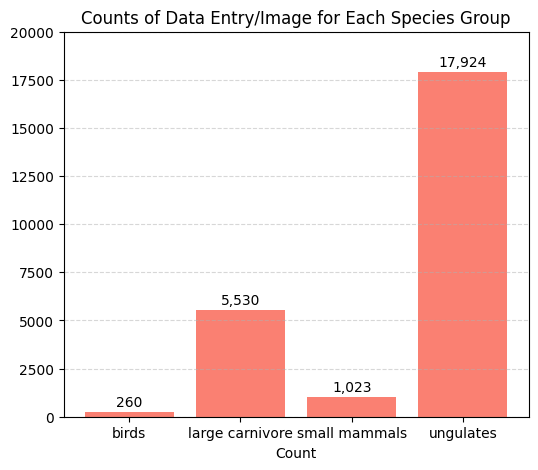

In [7]:
# Check class counts for each species group
counts= df.groupby(['species_group'])['species_group'].count()

plt.figure(figsize=(6,5))
plot = plt.bar(counts.index, counts.values, color='salmon')
plt.bar_label(plot, labels=[f"{v:,}" for v in counts.values], padding=2)
plt.xlabel('Count')
plt.ylim(0,20000)
plt.title('Counts of Data Entry/Image for Each Species Group')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

Extreme class imbalance was detected, need to be handled during modelling process.

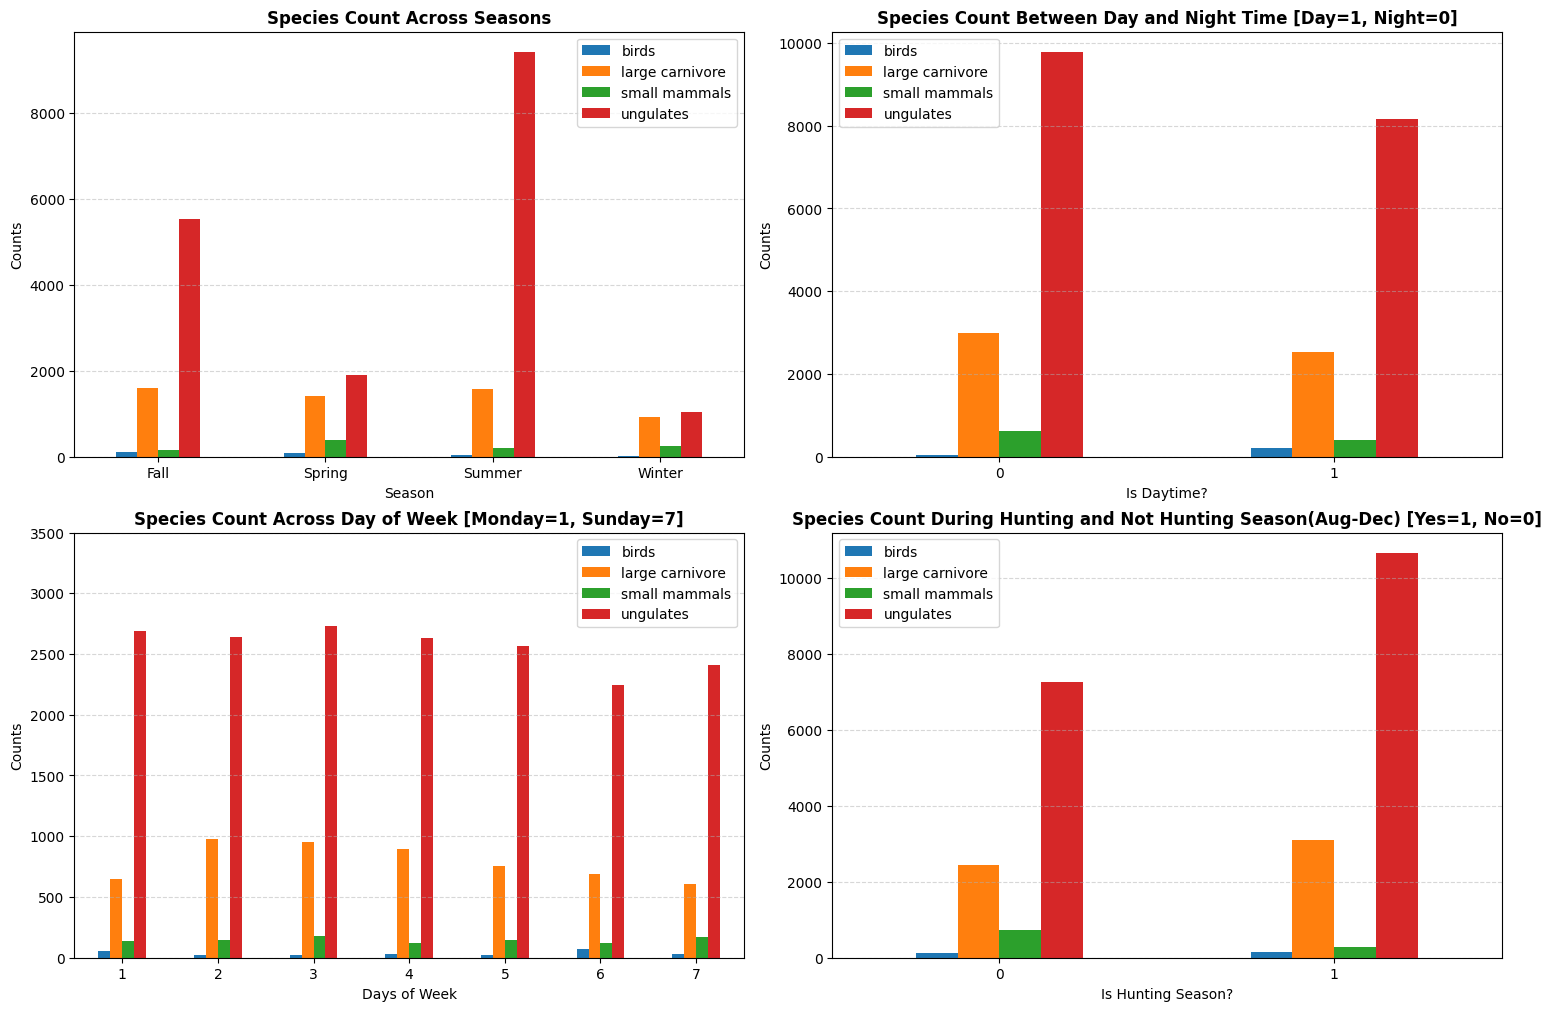

In [8]:
# count of species group across each season, location_id, time of day, day of week, hunting season
counts_season = df.groupby(['season', 'species_group']).size().unstack(fill_value=0)
counts_daytime = df.groupby(['is_daytime', 'species_group']).size().unstack(fill_value=0)
# counts_weekday = df.groupby(['is_weekend', 'species_group']).size().unstack(fill_value=0)
counts_weekday = df.groupby(['day_of_week', 'species_group']).size().unstack(fill_value=0)
counts_hunting = df.groupby(['is_hunting_season', 'species_group']).size().unstack(fill_value=0)

fig, axes = plt.subplots(2, 2, figsize=(15, 10), constrained_layout=True)

counts_season.plot(kind='bar', ax=axes[0,0]) 
axes[0,0].set_xlabel('Season')
axes[0,0].set_ylabel('Counts')
axes[0,0].grid(axis='y', linestyle='--', alpha=0.5)
axes[0,0].set_xticklabels(axes[0,0].get_xticklabels(), rotation=0)
axes[0,0].set_title('Species Count Across Seasons', fontweight='bold')
axes[0,0].legend()

counts_daytime.plot(kind='bar', ax=axes[0,1]) 
axes[0,1].set_xlabel('Is Daytime?')
axes[0,1].set_ylabel('Counts')
axes[0,1].grid(axis='y', linestyle='--', alpha=0.5)
axes[0,1].set_xticklabels(axes[0,1].get_xticklabels(), rotation=0)
axes[0,1].set_title('Species Count Between Day and Night Time [Day=1, Night=0]', fontweight='bold')
axes[0,1].legend()

# counts_weekday.plot(kind='bar', ax=axes[1,0])
# axes[1,0].set_xlabel('Is Weekend?')
# axes[1,0].set_ylabel('Counts')
# axes[1,0].grid(axis='y', linestyle='--', alpha=0.5)
# axes[1,0].set_xticklabels(axes[1,0].get_xticklabels(), rotation=0)
# axes[1,0].set_title('Species Count During Weekend and Weekday [weekend=1, weekday=0]')
# axes[1,0].legend()

counts_weekday.plot(kind='bar', ax=axes[1,0]) 
axes[1,0].set_xlabel('Days of Week')
axes[1,0].set_ylabel('Counts')
axes[1,0].set_ylim(0, 3500)
axes[1,0].grid(axis='y', linestyle='--', alpha=0.5)
axes[1,0].set_xticklabels(axes[1,0].get_xticklabels(), rotation=0)
axes[1,0].set_title('Species Count Across Day of Week [Monday=1, Sunday=7]', fontweight='bold')
axes[1,0].legend()

counts_hunting.plot(kind='bar', ax=axes[1,1]) 
axes[1,1].set_xlabel('Is Hunting Season?')
axes[1,1].set_ylabel('Counts')
axes[1,1].grid(axis='y', linestyle='--', alpha=0.5)
axes[1,1].set_xticklabels(axes[1,1].get_xticklabels(), rotation=0)
axes[1,1].set_title('Species Count During Hunting and Not Hunting Season(Aug-Dec) [Yes=1, No=0]', fontweight='bold')
axes[1,1].legend()

### MLR Model Building and Training

In [9]:
# Features to use for prediction: location_id, is_daytime, season, is_hunting_season

# One-hot encoding
X = pd.get_dummies(
    df[['location_id', 'season', 'is_daytime', 'is_hunting_season']], 
    columns=['location_id', 'season', 'is_daytime', 'is_hunting_season'], 
    drop_first=True
)

y = df['species_group']

# X.head()
# y.head()

In [10]:
# train/val/test split (70/15/15%)

# split data to train set & temp set (val+test)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=100, stratify=y)

# split temp set to val and test set (equal split of the 30%)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=100, stratify=y_temp)


# check shape
print("Shapes:")
print("X_train=", X_train.shape, "; X_train_val=", X_val.shape, "; X_test=", X_test.shape)
print("y_train=", y_train.shape, "; y_train_val=", y_val.shape, "; y_test=", y_test.shape)

Shapes:
X_train= (17315, 31) ; X_train_val= (3711, 31) ; X_test= (3711, 31)
y_train= (17315,) ; y_train_val= (3711,) ; y_test= (3711,)


In [11]:
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# build model & train 
lr_pipe = make_pipeline(
    LogisticRegression(class_weight='balanced')  # class_weight='balanced' to tackle class imbalance
)

param_dist = {
    'logisticregression__C': loguniform(1e-3, 1e2),
    'logisticregression__solver': ['lbfgs', 'newton-cg', 'saga'],
    'logisticregression__max_iter': [500, 1000, 2000]
}

# cross-validation
cv=RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=100)

# randomized search for hyperparameter tuning
search = RandomizedSearchCV(
    lr_pipe, 
    param_dist,
    n_iter=20,
    scoring='f1_macro', #computes F1-score for each class separately. Takes the average, giving equal weight to every class
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=100
)

search.fit(X_train, y_train)

Fitting 25 folds for each of 20 candidates, totalling 500 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...'balanced'))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'logisticregression__C': <scipy.stats....0021078AB7620>, 'logisticregression__max_iter': [500, 1000, ...], 'logisticregression__solver': ['lbfgs', 'newton-cg', ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validati

In [12]:
# check the results of RandomizedSearchCV 
results = pd.DataFrame(search.cv_results_)
results.sort_values(by="mean_test_score", ascending=False).head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_logisticregression__C,param_logisticregression__max_iter,param_logisticregression__solver,params,split0_test_score,split1_test_score,...,split18_test_score,split19_test_score,split20_test_score,split21_test_score,split22_test_score,split23_test_score,split24_test_score,mean_test_score,std_test_score,rank_test_score
17,0.537503,0.092287,0.021643,0.005052,1.415532,1000,lbfgs,"{'logisticregression__C': 1.4155319698681557, ...",0.567179,0.545387,...,0.556013,0.557585,0.540782,0.520684,0.542274,0.576942,0.564106,0.541863,0.021169,1
4,0.583294,0.099270,0.020835,0.002719,1.322999,2000,lbfgs,"{'logisticregression__C': 1.322998773079727, '...",0.561595,0.543720,...,0.556013,0.557585,0.540782,0.521032,0.542274,0.576942,0.563972,0.541547,0.021308,2
19,0.700436,0.230091,0.026871,0.012007,15.158599,1000,lbfgs,"{'logisticregression__C': 15.158599021135453, ...",0.562700,0.542902,...,0.558969,0.557585,0.544274,0.520128,0.551403,0.576608,0.555298,0.541241,0.020571,3
14,0.592927,0.172642,0.023920,0.008353,28.317690,2000,lbfgs,"{'logisticregression__C': 28.317689614086948, ...",0.562700,0.542902,...,0.558073,0.557585,0.544274,0.521032,0.542274,0.576608,0.554796,0.540950,0.022467,4
8,0.369546,0.073300,0.027787,0.009255,0.036038,500,newton-cg,"{'logisticregression__C': 0.03603841406774761,...",0.537245,0.496664,...,0.531170,0.505856,0.487619,0.489413,0.510273,0.497422,0.503930,0.496804,0.015803,5


In [13]:
# check values of best combo found for parameters
print(search.best_params_)

{'logisticregression__C': np.float64(1.4155319698681557), 'logisticregression__max_iter': 1000, 'logisticregression__solver': 'lbfgs'}


### Validation Set Prediction (For tuning if required)

In [14]:
#predict with val set

best_model = LogisticRegression(
    C = 1.4155319698681557,
    solver = 'lbfgs',
    max_iter = 1000,
    class_weight = 'balanced'
)
best_model.fit(X_train, y_train)
val_pred = best_model.predict(X_val)

In [20]:
# overall accuracy
accuracy = accuracy_score(y_val, val_pred)

# macro precision, recall, F1 (treat all classes equally)
precision = precision_score(y_val, val_pred, average='macro')
recall = recall_score(y_val, val_pred, average='macro')
f1 = f1_score(y_val, val_pred, average='macro')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f} \n")

# full breakdown by class
print(classification_report(y_val, val_pred))


Accuracy: 0.7774
Precision: 0.5312
Recall: 0.7196
F1 Score: 0.5652 

                 precision    recall  f1-score   support

          birds       0.14      0.69      0.23        39
large carnivore       0.65      0.54      0.59       829
  small mammals       0.44      0.80      0.57       154
      ungulates       0.90      0.85      0.87      2689

       accuracy                           0.78      3711
      macro avg       0.53      0.72      0.57      3711
   weighted avg       0.81      0.78      0.79      3711



<Figure size 800x600 with 0 Axes>

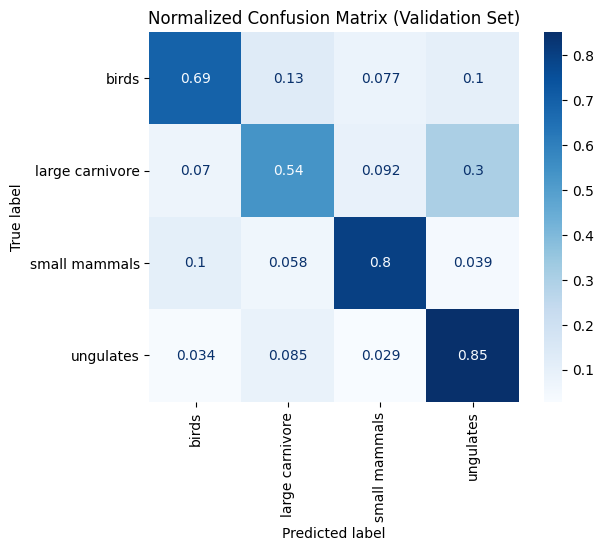

In [16]:
# Validation set confusion matrix 
cm = confusion_matrix(y_val, val_pred, normalize='true')

# plot cm
plt.figure(figsize=(8,6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=search.best_estimator_.classes_)
ax = disp.plot(xticks_rotation=90, cmap='Blues').ax_
ax.grid(False)

cbar = disp.im_.colorbar
cbar.ax.spines['outline'].set_visible(False)

for spine in ax.spines.values():   # remove border box
    spine.set_visible(False)
plt.title("Normalized Confusion Matrix (Validation Set)")
plt.show()


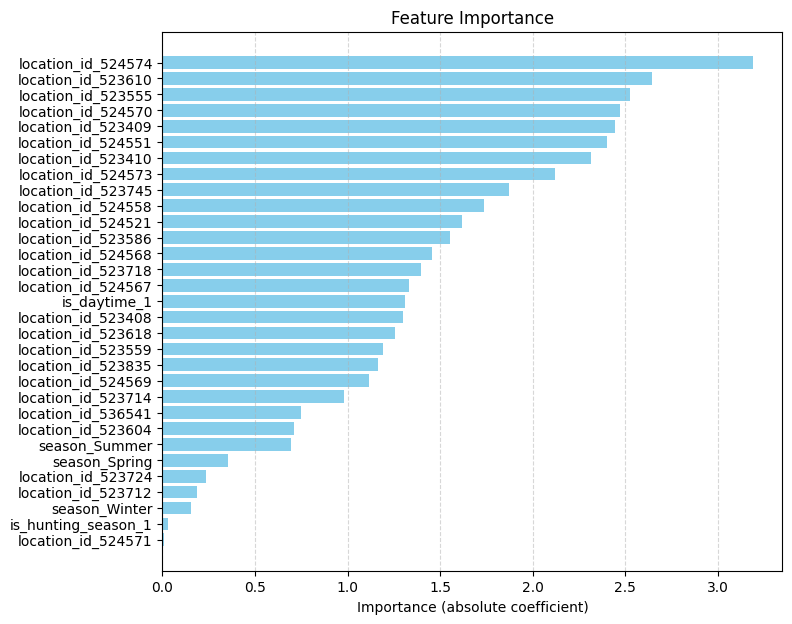

In [17]:
# feature importance plot

# get feature names
feature_names = X_train.columns

# get absolute coefficients (importance)
importance = np.abs(best_model.coef_[0])

# put into a DataFrame
df_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importance
}).sort_values('importance', ascending=False)

plt.figure(figsize=(8,7))
plt.barh(df_imp['feature'], df_imp['importance'], color='skyblue')
plt.xlabel('Importance (absolute coefficient)')
plt.title('Feature Importance')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.gca().invert_yaxis()
plt.show()

### Test Set Prediction

In [18]:
# predict with test set
y_pred = best_model.predict(X_test)

# overall accuracy
accuracy = accuracy_score(y_test, y_pred)

# macro precision, recall, F1 (treat all classes equally)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

print("Test set prediction metrics: \n")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f} \n")

# full breakdown by class
print(classification_report(y_test, y_pred))

Test set prediction metrics: 

Accuracy: 0.7639
Precision: 0.5083
Recall: 0.6896
F1 Score: 0.5401 

                 precision    recall  f1-score   support

          birds       0.15      0.72      0.25        39
large carnivore       0.60      0.50      0.54       830
  small mammals       0.39      0.69      0.50       153
      ungulates       0.89      0.85      0.87      2689

       accuracy                           0.76      3711
      macro avg       0.51      0.69      0.54      3711
   weighted avg       0.80      0.76      0.78      3711



<Figure size 800x600 with 0 Axes>

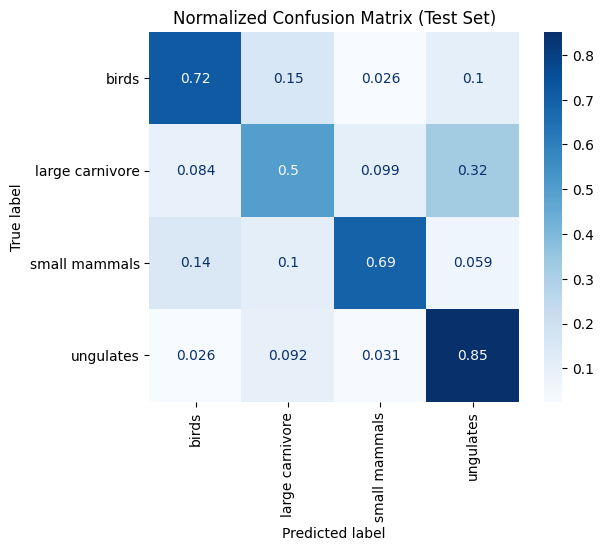

In [19]:
# Test set confusion matrix
cm = confusion_matrix(y_test, y_pred, normalize='true')

# plot cm
plt.figure(figsize=(8,6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=search.best_estimator_.classes_)
ax = disp.plot(xticks_rotation=90, cmap='Blues').ax_
ax.grid(False)

cbar = disp.im_.colorbar
cbar.ax.spines['outline'].set_visible(False)

for spine in ax.spines.values():   # remove border box
    spine.set_visible(False)

plt.title("Normalized Confusion Matrix (Test Set)")
plt.show()